# Feature-importance overview for each model and cross model comparison

Note: raw numbers are not comparable across models.

## Imports & load four importance tables

In [40]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TABLES = Path("../results/tables")
FIGURES = Path("../results/figures"); FIGURES.mkdir(parents=True, exist_ok=True)

MODELS = {
    "LASSO_mRNA":       "feature_importance_lasso_mrna.csv",
    "LASSO_multiomics": "feature_importance_lasso_multiomics.csv",
    "NN_mRNA":          "feature_importance_nn_mrna.csv",
    "NN_integrated":    "feature_importance_nn_integrated.csv",
}
tables = {}
for model, fname in MODELS.items():
    path = TABLES / fname
    if not path.exists():
        raise FileNotFoundError(f"Missing {path} - run stage 19a/19b first.")
    tables[model] = pd.read_csv(path)

print("Loaded:", {m: len(df) for m, df in tables.items()})

Loaded: {'LASSO_mRNA': 50, 'LASSO_multiomics': 577, 'NN_mRNA': 50, 'NN_integrated': 340}


## Create short, readable feature label

`RNA: ESR1` stays `ESR1`; `METH: ESR1 (cg00920970)` becomes `ESR1 (cg00920970)` so the charts and
tables read cleanly.

In [41]:
def short_label(row):
    if row["modality"] == "RNA":
        return row["gene"]
    return f"{row['gene']} ({row['cpg']})"

for df in tables.values():
    df["label"] = df.apply(short_label, axis=1)

## Top 15 features per model


In [42]:
TOP_N = 15

def top_table(model):
    df = tables[model]
    cols = ["rank", "label", "modality", "importance"]
    if "selection_frequency" in df.columns:
        cols.append("selection_frequency")
    out = df.sort_values("importance", ascending=False).head(TOP_N)[cols].reset_index(drop=True)
    return out.round(4)

for model in MODELS:
    print(f"\n===== {model} — top {TOP_N} =====")
    print(top_table(model).to_string(index=False))

# Save one tidy file with every model's top-15 stacked together.
combined = pd.concat(
    [tables[m].sort_values("importance", ascending=False).head(TOP_N) for m in MODELS],
    ignore_index=True)
keep = ["model", "rank", "label", "modality", "gene", "cpg", "importance"]
if "selection_frequency" in combined.columns:
    keep.append("selection_frequency")
combined[keep].to_csv(TABLES / "feature_importance_overview_top15.csv", index=False)


===== LASSO_mRNA — top 15 =====
 rank label modality  importance  selection_frequency
    1 BLVRA      RNA      0.1579                 0.84
    2  EXO1      RNA      0.1225                 0.16
    3 NDC80      RNA      0.1190                 0.20
    4 MMP11      RNA      0.0977                 0.68
    5  KRT5      RNA      0.0952                 0.44
    6  MELK      RNA      0.0943                 0.16
    7 PTTG1      RNA      0.0879                 0.16
    8 KIF2C      RNA      0.0857                 0.20
    9  MAPT      RNA      0.0786                 0.40
   10  NUF2      RNA      0.0758                 0.16
   11  ANLN      RNA      0.0738                 0.20
   12  RRM2      RNA      0.0636                 0.12
   13 MYBL2      RNA      0.0621                 0.12
   14 KRT14      RNA      0.0619                 0.12
   15  MLPH      RNA      0.0591                 0.52

===== LASSO_multiomics — top 15 =====
 rank              label modality  importance  selection_frequen

## Figure 1: importance ranking per model

Blue = expression (RNA), red = methylation
(METH). Note each panel has its own x-axis scale, do not compare bar lengths between panels.

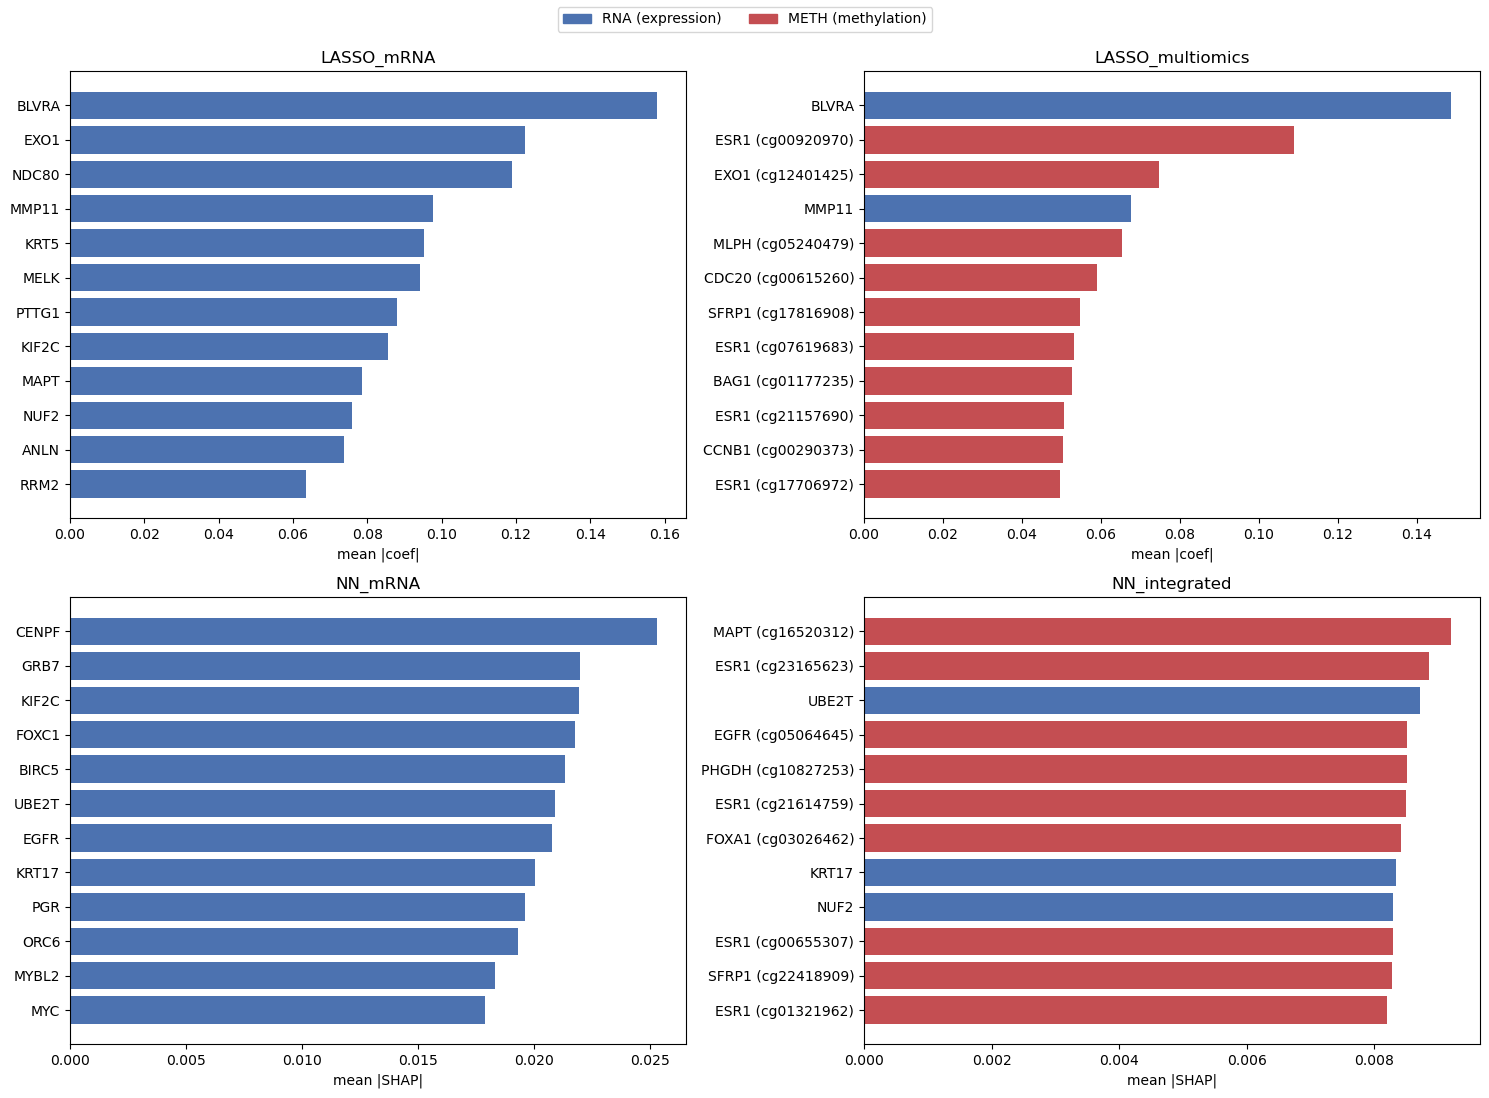

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, model in zip(axes.ravel(), MODELS):
    d = tables[model].sort_values("importance", ascending=False).head(12).iloc[::-1]
    colors = ["#4C72B0" if m == "RNA" else "#C44E52" for m in d["modality"]]
    ax.barh(d["label"], d["importance"], color=colors)
    metric = "mean |coef|" if model.startswith("LASSO") else "mean |SHAP|"
    ax.set_xlabel(metric); ax.set_title(model)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ("#4C72B0", "#C44E52")]
fig.legend(handles, ["RNA (expression)", "METH (methylation)"], loc="upper center", ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIGURES / "feature_importance_overview.png", dpi=300)
plt.show()

## Figure 2: LASSO selection frequency

For the two LASSO models, how often each feature was kept across the 25 fits. Implemented bc we observed instability during the first training.

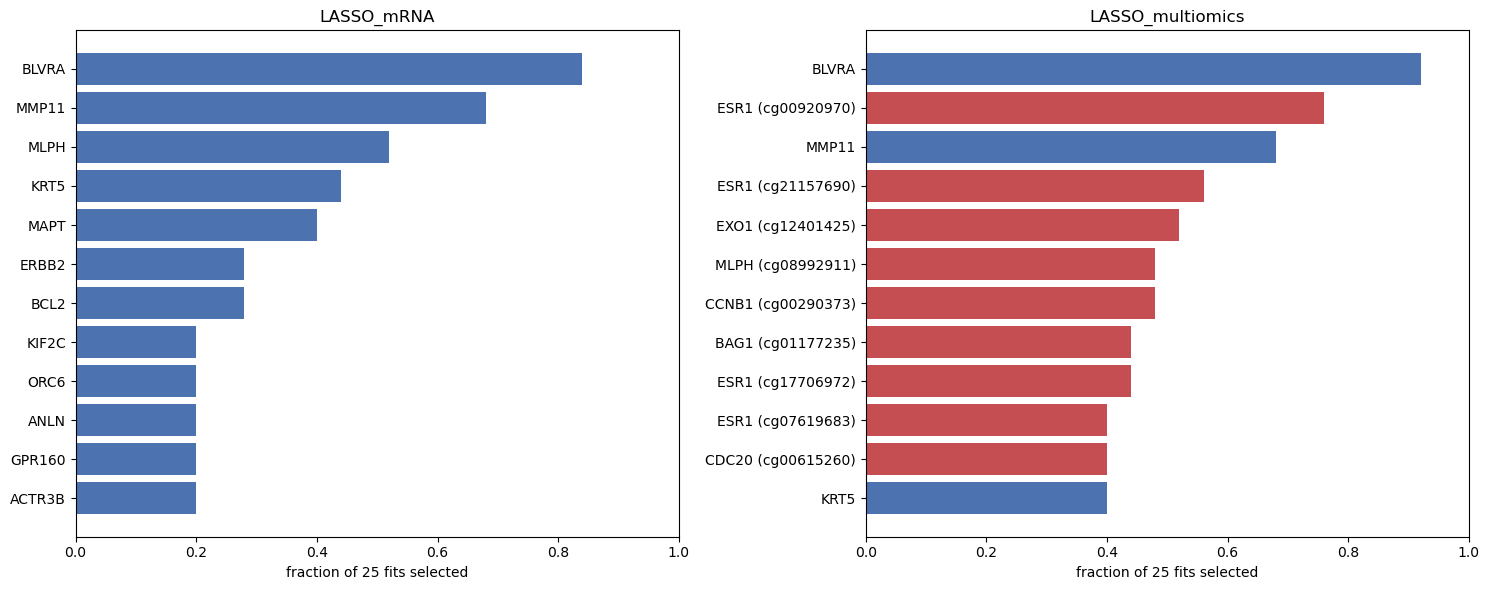

In [44]:
lasso_models = [m for m in MODELS if "selection_frequency" in tables[m].columns]

fig, axes = plt.subplots(1, len(lasso_models), figsize=(7.5 * len(lasso_models), 6))
if len(lasso_models) == 1:
    axes = [axes]

for ax, model in zip(axes, lasso_models):
    d = tables[model].sort_values("selection_frequency", ascending=False).head(12).iloc[::-1]
    colors = ["#4C72B0" if m == "RNA" else "#C44E52" for m in d["modality"]]
    ax.barh(d["label"], d["selection_frequency"], color=colors)
    ax.set_xlim(0, 1)
    ax.set_xlabel("fraction of 25 fits selected"); ax.set_title(model)

plt.tight_layout()
plt.savefig(FIGURES / "feature_importance_lasso_selection_frequency.png", dpi=300)
plt.show()

## Figure 3: cross-model consistency counter

For each model we take its top 15 genes (collapsing a genes CpGs to its best feature), then count, per gene, in how many
of the 4 models it lands in the top 10. Resulting in a number from 0 to 4. We show everything that appears in at least 2. Each bar is stacked and coloured by which
models agree. green hues are Neural Networks and red hues are LASSO Models.

Genes in the top 15 of >= 2 models:
 gene  n_models                                   models
SFRP1         3 LASSO_multiomics, NN_mRNA, NN_integrated
MYBL2         3       LASSO_mRNA, NN_mRNA, NN_integrated
 MAPT         2                LASSO_mRNA, NN_integrated
UBE2T         2                   NN_mRNA, NN_integrated
 NUF2         2                LASSO_mRNA, NN_integrated
MMP11         2             LASSO_mRNA, LASSO_multiomics
 MLPH         2             LASSO_mRNA, LASSO_multiomics
 MELK         2                      LASSO_mRNA, NN_mRNA
BLVRA         2             LASSO_mRNA, LASSO_multiomics
 EGFR         2                   NN_mRNA, NN_integrated
KRT17         2                   NN_mRNA, NN_integrated
KIF2C         2                      LASSO_mRNA, NN_mRNA
 GRB7         2                   NN_mRNA, NN_integrated
FOXA1         2          LASSO_multiomics, NN_integrated
 EXO1         2             LASSO_mRNA, LASSO_multiomics
 ESR1         2          LASSO_multiomics, NN_integr

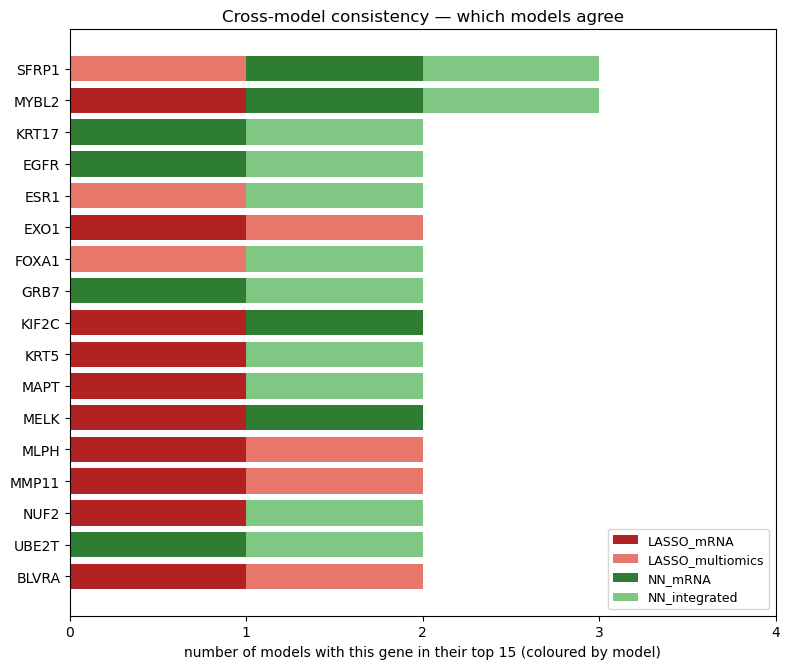

In [45]:
K = 15

# each model's top-K genes (collapse CpGs to gene via the gene's best feature)
model_topk = {}
for model, df in tables.items():
    gene_best = df.groupby("gene")["importance"].max().sort_values(ascending=False)
    model_topk[model] = list(gene_best.head(K).index)

# for every gene: how many models rank it in their top K, and which ones
from collections import defaultdict
in_models = defaultdict(list)
for model, genes in model_topk.items():
    for g in genes:
        in_models[g].append(model)

rec = pd.DataFrame([{"gene": g, "n_models": len(ms), "models": ", ".join(ms)}
                    for g, ms in in_models.items()])
rec = rec[rec["n_models"] >= 2].sort_values(["n_models", "gene"]).reset_index(drop=True)
rec.to_csv(TABLES / "feature_importance_topK_recurrence.csv", index=False)
print(f"Genes in the top {K} of >= 2 models:")
print(rec.sort_values("n_models", ascending=False).to_string(index=False))

# Stacked bar: one segment per model that has the gene in its top K, coloured by model.
MODEL_COLORS = {"LASSO_mRNA": "#B22222", "LASSO_multiomics": "#E8776B",
                "NN_mRNA": "#2E7D32", "NN_integrated": "#81C784"}
d = rec.sort_values("n_models")
genes = d["gene"].tolist()
present = pd.DataFrame(0, index=genes, columns=list(MODELS))
for _, row in d.iterrows():
    for m in row["models"].split(", "):
        present.loc[row["gene"], m] = 1

plt.figure(figsize=(8, max(4, 0.4 * len(genes))))
left = np.zeros(len(genes))
for model in MODELS:
    plt.barh(genes, present[model].values, left=left,
             color=MODEL_COLORS[model], label=model)
    left += present[model].values
plt.xlim(0, 4); plt.xticks([0, 1, 2, 3, 4])
plt.xlabel(f"number of models with this gene in their top {K} (coloured by model)")
plt.title("Cross-model consistency — which models agree")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / "feature_importance_consistency_counter.png", dpi=300)
plt.show()

## Summary

Outputs:

- `feature_importance_overview_top15.csv` 
- `feature_importance_overview.png` 
- `feature_importance_lasso_selection_frequency.png`
- `feature_importance_topK_recurrence.csv` / `feature_importance_consistency_counter.png`
